# 04 — Grid Search of Dynamics

Holding geometry fixed (5d torus, uniform), vary the three forming-force
coefficients on a 3×3×3 grid, 3 replicates each = 81 runs × 500 steps.
Records constraint + 3 components every 100 steps.

In [1]:
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from abm_core import init_torus_uniform
from experiment_grid_search import run_grid_cell

# Fixed factors
N = 300
D = 5
BUDGET = 10
N_STEPS = 500
SNAPSHOT_TIMES = [0, 100, 200, 300, 400, 500]
REPLICATES = 3

# Varied factors
LEVELS = {
    "b_homophily":  [0.0, 1.0, 3.0],
    "b_triadic":    [0.0, 0.5, 1.5],
    "b_popularity": [0.0, 0.2, 0.6],
}

OUT_DIR = Path("simulations/grid_search_torus_5d")
RUNS_DIR = OUT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = OUT_DIR / "summary.parquet"


In [2]:
# One init per replicate (block design): all cells share an init within a block,
# different blocks use different inits.
inits = [init_torus_uniform(n=N, d=D, rng=np.random.default_rng(seed))
         for seed in range(REPLICATES)]

cells = list(product(LEVELS["b_homophily"],
                     LEVELS["b_triadic"],
                     LEVELS["b_popularity"]))
print(f"{len(cells)} cells × {REPLICATES} replicates = {len(cells) * REPLICATES} runs")


27 cells × 3 replicates = 81 runs


In [3]:
all_rows = []
total = len(cells) * REPLICATES
with tqdm(total=total, desc="grid runs") as pbar:
    for cell_idx, (b_h, b_t, b_p) in enumerate(cells):
        for rep in range(REPLICATES):
            sim_seed = rep * 1000 + cell_idx
            out_path = RUNS_DIR / f"cell_{cell_idx:02d}_rep{rep}.npz"
            if out_path.exists():
                # Reload metrics from disk to rebuild the summary row
                data = np.load(out_path)
                rows = []
                for i, t in enumerate(data["times"].tolist()):
                    row = {"b_homophily": b_h, "b_triadic": b_t, "b_popularity": b_p, "t": t}
                    for name in ("constraint", "c_size", "c_density", "c_hierarchy"):
                        arr = data[name][i]
                        row[f"mean_{name}"] = float(arr.mean())
                        row[f"median_{name}"] = float(np.median(arr))
                        row[f"std_{name}"] = float(arr.std())
                    rows.append(row)
            else:
                rows = run_grid_cell(
                    init_result=inits[rep],
                    b_homophily=b_h,
                    b_triadic=b_t,
                    b_popularity=b_p,
                    budget=BUDGET,
                    n_steps=N_STEPS,
                    snapshot_times=SNAPSHOT_TIMES,
                    sim_seed=sim_seed,
                    out_path=out_path,
                )
            for row in rows:
                row["cell_id"] = cell_idx
                row["replicate"] = rep
            all_rows.extend(rows)
            pbar.update(1)

summary = pd.DataFrame(all_rows)
summary.to_parquet(SUMMARY_PATH)
print(f"Saved {len(summary)} rows → {SUMMARY_PATH}")
summary.head()

grid runs:   0%|          | 0/81 [00:00<?, ?it/s]

Saved 486 rows → simulations/grid_search_torus_5d/summary.parquet


,b_homophily,b_triadic,b_popularity,t,mean_constraint,median_constraint,std_constraint,mean_c_size,median_c_size,std_c_size,mean_c_density,median_c_density,std_c_density,mean_c_hierarchy,median_c_hierarchy,std_c_hierarchy,cell_id,replicate
0,0.0,0.0,0.0,0,1.000000,1.0000,0.000000,1.000000,1.0,0.000000,0.000000,0.000,0.000000,0.000000,0.0000,0.000000,0,0
1,0.0,0.0,0.0,100,0.105744,0.1042,0.005040,0.100157,0.1,0.001698,0.005265,0.004,0.004383,0.000322,0.0002,0.000317,0,0
2,0.0,0.0,0.0,200,0.105744,0.1042,0.005040,0.100157,0.1,0.001698,0.005265,0.004,0.004383,0.000322,0.0002,0.000317,0,0
3,0.0,0.0,0.0,300,0.105654,0.1042,0.004894,0.100083,0.1,0.001441,0.005251,0.004,0.004359,0.000320,0.0002,0.000312,0,0
4,0.0,0.0,0.0,400,0.105654,0.1042,0.004894,0.100083,0.1,0.001441,0.005251,0.004,0.004359,0.000320,0.0002,0.000312,0,0


In [4]:
summary = pd.read_parquet(SUMMARY_PATH)

# Baseline cell: only intercept drives ties → saturated near-random graph,
# mean_constraint stabilizes around 1/budget (≈ 0.10 with budget=10)
baseline = summary[
    (summary["b_homophily"] == 0)
    & (summary["b_triadic"] == 0)
    & (summary["b_popularity"] == 0)
    & (summary["t"] == N_STEPS)
]
print("Baseline (all-zero) at t=500, mean_constraint per replicate:")
print(baseline[["replicate", "mean_constraint", "std_constraint"]])
assert baseline["mean_constraint"].std() < 0.01, "baseline should be tight across replicates"

# Highest-pressure cell — should produce noticeably more constraint than baseline
all_high = summary[
    (summary["b_homophily"] == 3.0)
    & (summary["b_triadic"] == 1.5)
    & (summary["b_popularity"] == 0.6)
    & (summary["t"] == N_STEPS)
]
print("\nAll-high (homophily=3, triadic=1.5, popularity=0.6) at t=500:")
print(all_high[["replicate", "mean_constraint", "std_constraint"]])
assert all_high["mean_constraint"].mean() > baseline["mean_constraint"].mean(), \
    "high-mechanism cells should yield more constraint than baseline"

Baseline (all-zero) at t=500, mean_constraint per replicate:
    replicate  mean_constraint  std_constraint
5           0         0.105654        0.004894
11          1         0.105520        0.004988
17          2         0.105092        0.004480

All-high (homophily=3, triadic=1.5, popularity=0.6) at t=500:
     replicate  mean_constraint  std_constraint
473          0         0.153861        0.018574
479          1         0.154419        0.018040
485          2         0.154415        0.017618


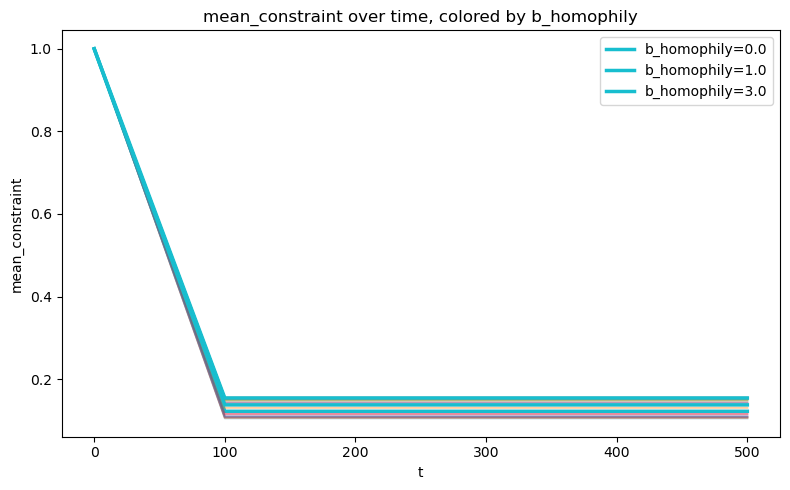

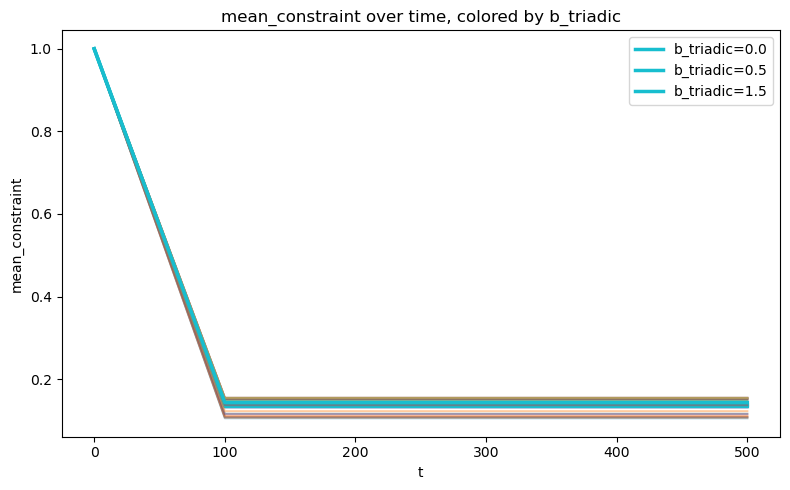

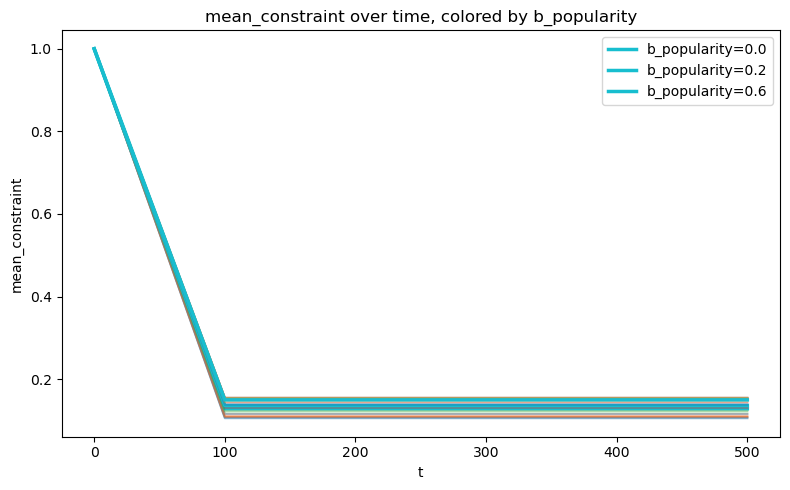

In [5]:
def plot_trajectories(summary, color_by, metric="mean_constraint"):
    fig, ax = plt.subplots(figsize=(8, 5))
    grouped = summary.groupby(["b_homophily", "b_triadic", "b_popularity", "t"])
    agg = grouped[metric].agg(["mean", "std"]).reset_index()
    for level, subset in agg.groupby(color_by):
        for cell_key, line in subset.groupby(
            [c for c in ("b_homophily", "b_triadic", "b_popularity") if c != color_by]
        ):
            ax.plot(line["t"], line["mean"], alpha=0.4)
        # bold mean across cells with this level for the legend
        bold = subset.groupby("t")["mean"].mean()
        ax.plot(bold.index, bold.values, label=f"{color_by}={level}", linewidth=2.5)
    ax.set_xlabel("t")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} over time, colored by {color_by}")
    ax.legend()
    plt.tight_layout()
    plt.show()

for color_by in ("b_homophily", "b_triadic", "b_popularity"):
    plot_trajectories(summary, color_by, metric="mean_constraint")


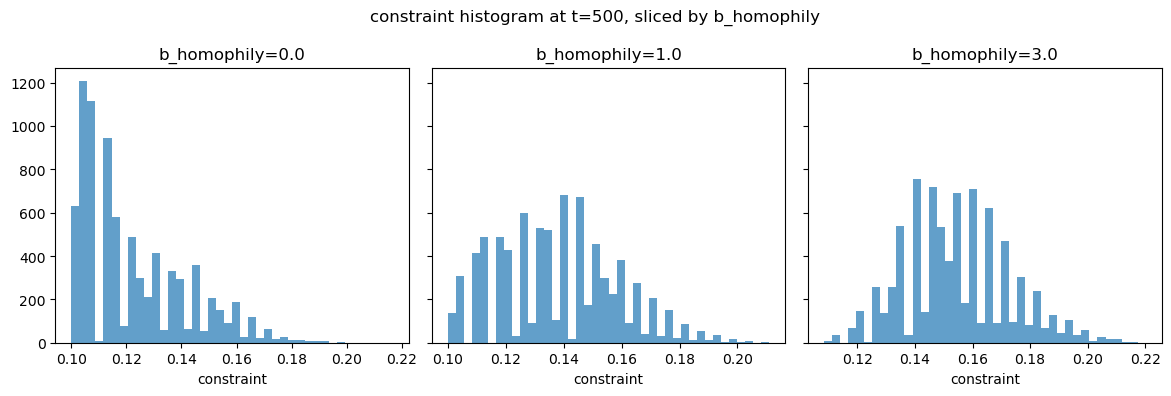

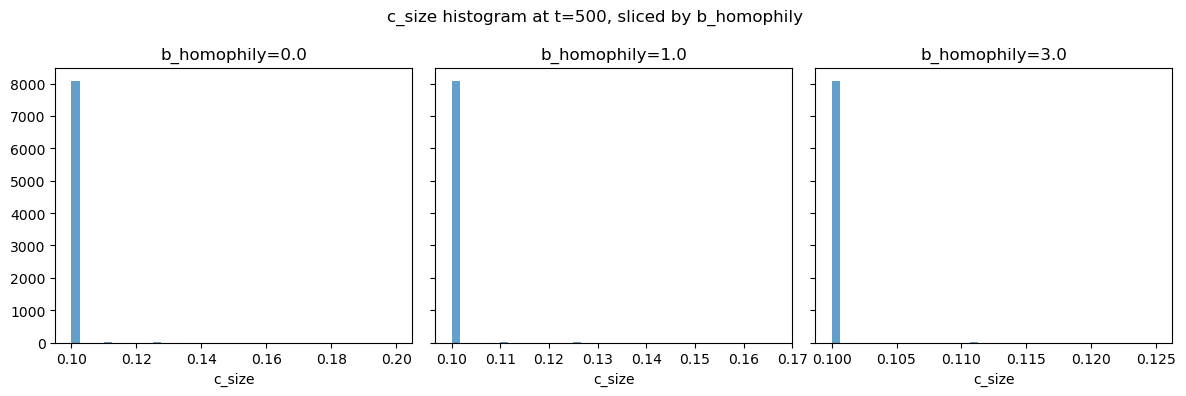

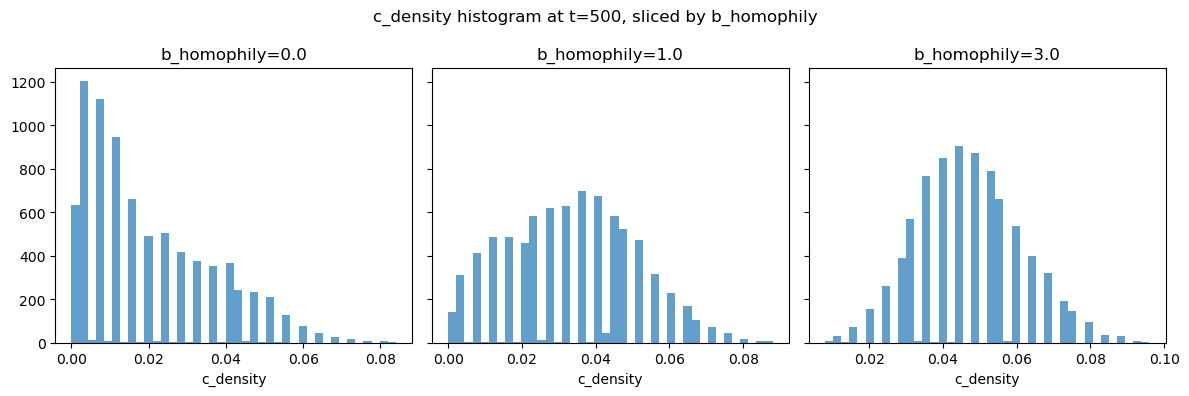

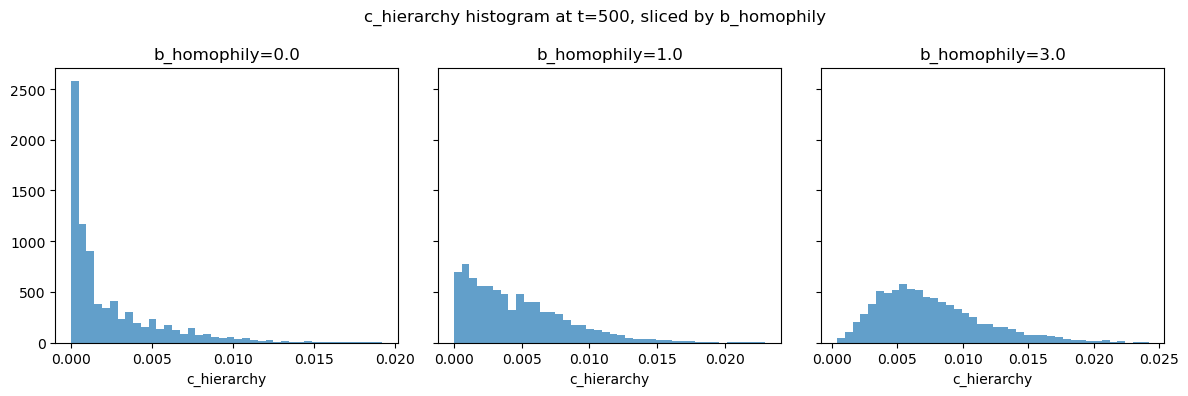

In [6]:
def plot_histograms_at_t(snapshot_t, metric, slice_by):
    """Pool per-node values across replicates, plot histogram per level of slice_by."""
    levels = sorted(LEVELS[slice_by])
    fig, axes = plt.subplots(1, len(levels), figsize=(4 * len(levels), 4), sharey=True)
    for ax, lvl in zip(axes, levels):
        # Pool across all cells with slice_by==lvl and across replicates
        cell_indices = [i for i, c in enumerate(cells)
                        if c[("b_homophily", "b_triadic", "b_popularity").index(slice_by)] == lvl]
        snap_idx = SNAPSHOT_TIMES.index(snapshot_t)
        all_vals = []
        for cell_idx in cell_indices:
            for rep in range(REPLICATES):
                data = np.load(RUNS_DIR / f"cell_{cell_idx:02d}_rep{rep}.npz")
                all_vals.append(data[metric][snap_idx])
        pooled = np.concatenate(all_vals)
        ax.hist(pooled, bins=40, alpha=0.7)
        ax.set_title(f"{slice_by}={lvl}")
        ax.set_xlabel(metric)
    fig.suptitle(f"{metric} histogram at t={snapshot_t}, sliced by {slice_by}")
    plt.tight_layout()
    plt.show()

for metric in ("constraint", "c_size", "c_density", "c_hierarchy"):
    plot_histograms_at_t(snapshot_t=N_STEPS, metric=metric, slice_by="b_homophily")
